## Week 04 Day 04: Deep Agents, the top layer

In [1]:
# Importing required libraries
from dotenv import load_dotenv
from IPython.display import Image, display, Markdown
from pydantic import BaseModel, Field
from langchain_openai import AzureChatOpenAI
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.graph.state import CompiledStateGraph
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend
import os
import sys
import json

import random
from typing import List, Optional, Annotated
from typing_extensions import TypedDict
from IPython.display import Markdown, display, Image
import gradio as gr
import urllib3
import requests
import re
import asyncio
import datetime
import win32com.client
import pythoncom
import subprocess
import time

load_dotenv(override = True)

True

In [2]:
# Let's see if the API key is working/helping us to call LLM from Azure Foundry
import os
# From OpenAI
AZURE_OPENAI_API_KEY= os.getenv("AZURE_OPENAI_API_KEY")
AZURE_OPENAI_MODEL_DEPLOYMENT = os.getenv("AZURE_OPENAI_DEPLOYMENT")
AZURE_OPENAI_ENDPOINT = os.getenv("AZURE_OPENAI_ENDPOINT")
AZURE_OPENAI_API_VERSION = os.getenv("AZURE_OPENAI_API_VERSION")
AZURE_OPENAI_DEPLOYMENT_GPT_41 = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_41")
AZURE_OPENAI_DEPLOYMENT_GPT_54_mini = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_54_mini")
AZURE_OPENAI_DEPLOYMENT_GPT_55 = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_55")
AZURE_OPENAI_DEPLOYMENT_GPT_4O_mini = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_4O_mini")
if AZURE_OPENAI_API_KEY:
    print("AZURE_OPENAI_API_KEY is available")
else:
    print("AZURE_OPENAI_API_KEY is not available")

# From Anthropic
AZURE_CLAUDE_DEPLOYMENT_OPUS_48=os.getenv("AZURE_CLAUDE_DEPLOYMENT_OPUS_48")
AZURE_CLAUDE_ENDPOINT=os.getenv("AZURE_CLAUDE_ENDPOINT")
AZURE_CLAUDE_API_KEY=os.getenv("AZURE_CLAUDE_API_KEY")
if AZURE_CLAUDE_API_KEY:
    print("AZURE_CLAUDE_API_KEY is avaiable")
else:
    print("AZURE_CLAUDE_API_KEY is not available")

# setting up tavily api key
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
SERP_API_KEY=os.getenv("SERP_API_KEY")
if SERP_API_KEY:
    print("SERP Available")
else:
    print("SERP Not Available")

EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS_TO")
if EMAIL_ADDRESS:
    print("Email address present!")
else:
    print("Email adderess not found!")

AZURE_OPENAI_API_KEY is available
AZURE_CLAUDE_API_KEY is avaiable
SERP Available
Email address present!


### Making Model Ready

In [3]:
## Setting up the llm from Azure Foundry
llm = AzureChatOpenAI(
    api_key = AZURE_OPENAI_API_KEY,
    azure_endpoint = AZURE_OPENAI_ENDPOINT,
    azure_deployment = AZURE_OPENAI_DEPLOYMENT_GPT_54_mini,
    api_version = AZURE_OPENAI_API_VERSION
)

### A web search tool

In [4]:
## setting up Serpapi as websearch tool for LLM

def list_serpapi_results(response: dict, max_results: int | None = None) -> list[dict]:
    """Print and return readable search results from a SerpApi response.

    The returned list contains only the fields normally needed by an agent:
    title, link, displayed_link, snippet, and position.
    """
    if not isinstance(response, dict):
        raise TypeError("response must be the dictionary returned by search_serpapi_debug")

    if response.get("error"):
        print(f"SerpApi error: {response['error']}")
        return []

    organic_results = response.get("organic_results", [])
    if not isinstance(organic_results, list):
        print("No readable organic_results list was found in the API response.")
        return []

    results = []
    print("\n ###########-printing SERP api response-############")
    for result in organic_results[:max_results]:
        if not isinstance(result, dict):
            continue

        item = {
            "position": result.get("position"),
            "title": result.get("title", "Untitled"),
            "link": result.get("link", ""),
            "displayed_link": result.get("displayed_link", ""),
            "snippet": result.get("snippet", ""),
        }
        results.append(item)

        print(f"{item['position']}. {item['title']}")
        print(f"   URL: {item['link']}")
        if item["snippet"]:
            print(f"   {item['snippet']}")
        print()

    if not results:
        print("The API response contains no organic search results.")

    return results

# setting up a google search api tool
@tool
def search_serpapi_tool(query: str) -> list[dict]:
    """Performs a search using SerpApi and prints raw response metadata if JSON parsing fails.
    Then print and return readable search results from a SerpApi response.
    """
    print("\n******************* SERP-API-TOOL-CALLED ************************\n")
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

    url = "https://serpapi.com/search"

    params = {"engine": "google", "q": query, "api_key": SERP_API_KEY, "num": 10}

    try:
        response = requests.get(url, params=params, verify=False)

        # 1. Print status code to see what the server actually answered
        print(f"[DEBUG] HTTP Status Code: {response.status_code}")

        # 2. Check if the response header is actually JSON
        content_type = response.headers.get("Content-Type", "")
        print(f"[DEBUG] Content-Type Header: {content_type}")

        # If it's an error page or HTML block, print the snippet to read the error
        if "application/json" not in content_type:
            print("[DEBUG] Received unexpected non-JSON body:")
            print(response.text[:500])  # Prints first 500 characters
            return {}

        return list_serpapi_results(response.json(), max_results=10) # List the results returned by the previous SerpApi call.
        
    except requests.exceptions.RequestException as e:
        print(f"An error occurred during the SerpApi call: {e}")
        return {}



# # --- Usage Example ---
# results = search_serpapi_debug(query="latest advancements in Agentic AI 2026")
# print(results)

## Setting up email sending method/tool 
# define a method/function to send email via Outlook COM
@tool
def send_email_tool( 
    subject: str,
    body: str
    ) -> bool:
    """Send an email using the local Outlook desktop client."""
    # Normalize recipient to a semicolon-separated string (Outlook format)
    recipient = EMAIL_ADDRESS
    recipients = []
    if isinstance(recipient, list):
        recipients = [r.strip() for r in recipient if r.strip()]
    elif isinstance(recipient, str):
        if "," in recipient:
            recipients = [r.strip() for r in recipient.split(",") if r.strip()]
        else:
            recipients = [recipient.strip()]
    
    def validate_email(email: str) -> bool:
        """Validate email format."""
        pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
        return re.match(pattern, email.strip()) is not None

    # Validate all recipients
    invalid_recipients = [r for r in recipients if not validate_email(r)]
    if invalid_recipients:
        print(f"Error: Invalid email format(s): {invalid_recipients}")
        return False
    
    recipient_str = "; ".join(recipients)
    
    if not recipient_str:
        print("Error: No recipients specified. Email not sent.")
        return False

    if body is None:
        body = "Hello there!! "

    print(f"\nSending email to {recipient_str} with subject '{subject}'...")

    # Ensure COM is initialized for the current thread (agent tool calls may run in worker threads).
    pythoncom.CoInitialize()
    try:
        # Connect to Outlook, launch it if not running
        outlook = None
        for attempt in range(5):
            try:
                outlook = win32com.client.Dispatch("Outlook.Application")
                outlook.GetNamespace("MAPI")
                print("Outlook is up & running...")
                break
            except Exception as e:
                if attempt == 0:
                    print("Outlook not running — launching...")
                    for p in [r"C:\Program Files\Microsoft Office\root\Office16\OUTLOOK.EXE",
                              r"C:\Program Files (x86)\Microsoft Office\root\Office16\OUTLOOK.EXE"]:
                        if os.path.exists(p):
                            subprocess.Popen([p])
                            time.sleep(45)
                            break
                    else:
                        print("Error: Outlook executable not found.")
                        return False
                elif attempt < 4:
                    print(f"Outlook connect attempt {attempt + 1}/5 — waiting...")
                    time.sleep(15)
                else:
                    print(f"Error: Outlook connect failed after 5 attempts: {e}")
                    return False

        try:
            mail = outlook.CreateItem(0)
            mail.To = recipient_str
            mail.Subject = subject
            mail.Body = body

            mail.Send()
            print(f"\nEmail sent successfully to '{recipient_str}' with subject '{subject}'.")
            return True

        except Exception as e:
            print(f"Failed to send email: {e}")
            # Print recipient info for debugging
            print(f"Debug - Recipients used: {repr(recipient_str)}")
            print(f"Debug - Recipient type: {type(recipient_str)}")
            return False
    finally:
        try:
            pythoncom.CoUninitialize()
        except Exception:
            pass

## binding the tools with llm
tools = [search_serpapi_tool, send_email_tool]
tools

[StructuredTool(name='search_serpapi_tool', description='Performs a search using SerpApi and prints raw response metadata if JSON parsing fails.\n    Then print and return readable search results from a SerpApi response.', args_schema=<class 'langchain_core.utils.pydantic.search_serpapi_tool'>, func=<function search_serpapi_tool at 0x00000256DE6934C0>),
 StructuredTool(name='send_email_tool', description='Send an email using the local Outlook desktop client.', args_schema=<class 'langchain_core.utils.pydantic.send_email_tool'>, func=<function send_email_tool at 0x00000256DFF43CE0>)]

### Make some handy functions/methods to call later

In [5]:
# making a function to make ready a user prompt with acutal prompt
def user_prompt(prompt: str) -> dict:
    message = {
        "messages":[
            {
                "role": "user",
                "content": prompt
            }
        ]
    }
    return message
user_prompt("What is my name")

# make a function to print the results of agent call in Markdown format
def print_markdown(result: dict) -> str:
    print("Agent's answer is as follows: \n")
    return display(Markdown(result['messages'][-1].content))

## Let's make a function of visualizing agent's structure
def draw_structure(agent: CompiledStateGraph) -> bytes:
    return display(Image(agent.get_graph().draw_png()))


# let's make a method to listdown the tool calls done by agent
def show_toolcalls(result: dict) -> list:
    tools_used = [toolcall['name'] for message in result['messages'] for toolcall in (getattr(message,"tool_calls", []) or [])]
    print("\nTools the agent called, in order: ")
    return tools_used

### A research agent that plans, searches and writes

In [ ]:
# let's make a directory for AI to use
sandbox = os.path.abspath("sandbox")
if sandbox:
    print("sandbox folder already exists!")
else:
    os.makedirs(sandbox, exist_ok=True)
    print("sandbox folder is been created!")

# create a deep agent
researcher = create_deep_agent(
    model = llm,
    tools = tools,
    system_prompt = (
        "You're a reseach analyst. Plan your work with your todo tool,"
        "research with search tool, and write your findings as a tidy markdown briefing to a file."
    ),
    backend=FilesystemBackend(
        root_dir=sandbox,
        virtual_mode=True
    )
)


sandbox folder already exists!


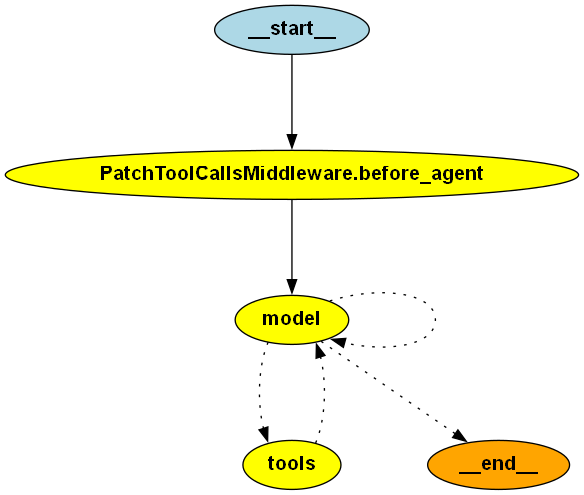

In [7]:
draw_structure(researcher)

In [11]:
# let's fire the deep research agent
brief = """
Our company is planning to move its sales fleet to electric vehicles.
Research the public EV charging landscape in the Bangalore, India: find out roughly how many public charging points there are,
and pick out two major charging networks a fleet could rely on.
Write a one page markdown briefing, with a heading and a short section for each, to the file charging.md.
"""

result = researcher.invoke(user_prompt(brief))
print_markdown(result)

[DEBUG] HTTP Status Code: 200
[DEBUG] Content-Type Header: application/json; charset=utf-8

 ###########-printing SERP api response-############
1. How Many EV Charging Stations Are in India? The 2026 ...
   URL: /goto?url=CAESkQEB6zswFTM1MZXtPkTf2m_bzfWCMjSgJAsSAhbt8j8w2ZpGfWnegaag7UCrlcomhYAiCL-1PY0crA5CMegZ6Tnvht2K07qnJ7XUqLZJwql3bs3ZqM_-XpEW-mdD0p-NxShhB4odOmnuZu3E8A0Yhf1WXX4Nym3U78_X_JpYAUh8smshiSNMHEGZ-0CVsL1UCGX8
   India has over 16,000 public EV charging stations operational across the country, spread across more than 200 Charge Point Operators (CPOs).

2. The INCKarnataka Government is building a strong and reliable ...
   URL: /goto?url=CAESywEB6zswFYBfxtD3_MNeO3APDT8kbKROU17wRoK1yoIcgsw_6cGb_InUYYz4LQ6oYk_NKj-gP9zELJmlLK9apHI2T88VVrxXAy2HVFKG0U7BzjWsQRwc4S35PX8DV-ZTwcM29iRHmOpbC091Yo_xwZ3vreAndOdftNKQhbYAvw3FsWc5-xFwJtWEaR-pUuDa-Rz6GK8F44zirWjP6sdHH2_k_Adx-tUSC5VFD8eeQTJUaqazv_Sd2cwABDPMuHTpbUfDipG8-IRUL_xkiA
   With 6,805 EV charging stations, #Karnataka now has the second

Done — I wrote the markdown briefing to `charging.md`.

In [13]:
# let's see which tools were called by agent
show_toolcalls(result)

Tools the agent called, in order: 


['ls',
 'search_serpapi_tool',
 'search_serpapi_tool',
 'search_serpapi_tool',
 'search_serpapi_tool',
 'search_serpapi_tool',
 'write_file']

### Sub-agents: handing off focused work

In [15]:
# Let's use a sub-agent
research_ev_instructions = """
You research one electric vehicle using the search tool and return three concise facts
that a fleet buyer would care about, such as price, range and charging.
"""

overall_instructions = """
You write comparison briefings for a company choosing electric vehicles for its sales fleet in Bangalore, India.
For each vehicle, delegate the research to your vehicle-researcher sub-agent,
then write a markdown comparison to a file,  ending with a clear recommendation.
"""

research_sub_agent = {
    "name": "vehicle-researcher",
    "description": "Researches a single electric vehicle and returns a short list of facts about it.",
    "system_prompt": research_ev_instructions
}
sandbox = os.path.abspath("sandbox") # directory

team_lead = create_deep_agent(
    model = llm,
    tools = tools,
    system_prompt = overall_instructions,
    subagents = [research_sub_agent],
    backend = FilesystemBackend(root_dir=sandbox, virtual_mode = True)
)

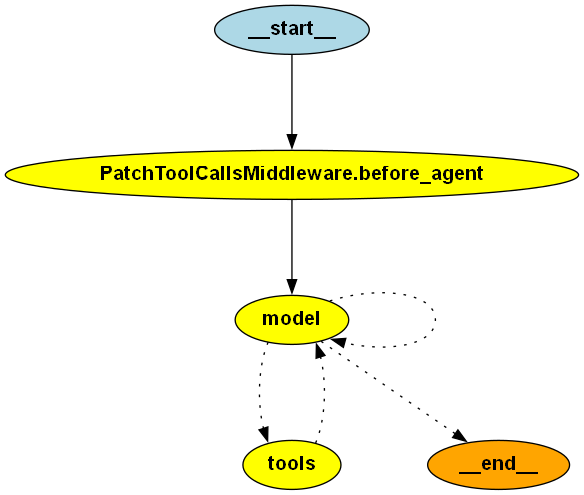

In [10]:
# let's see the structure of this deep agent
draw_structure(team_lead)

In [16]:
# let's call the deep agent with it's subagent
mission = """
Compare the MG Windsor EV  and Tata Nexon EV as candidates for our 100-car sales fleet.
Research each vehicle, then write a short markdown comparison with a recommendation to ev-fleet.md
"""
result = team_lead.invoke(user_prompt(mission))
print_markdown(result) # for printing deep-agent result
show_toolcalls(result) # see tools-called by agent


******************* SERP-API-TOOL-CALLED ************************


******************* SERP-API-TOOL-CALLED ************************

[DEBUG] HTTP Status Code: 200
[DEBUG] Content-Type Header: application/json; charset=utf-8

 ###########-printing SERP api response-############
1. Buy Windsor EV, MG Windsor EV Price in India
   URL: https://www.grouplandmark.in/MG-windsor-EV.html
   Starting at ₹13.50 lakh, with Battery-as-a-Service (₹3.9 per km) Travel up to 332 km on a single charge without range anxiety.

2. MG Windsor EV Detailed On Road Price in Mumbai
   URL: https://www.cardekho.com/mg/windsor-ev/price-in-mumbai
   MG Windsor EV Price in Mumbai starts from ₹14.70 Lakh. two battery packs: a 38 kWh standard (332 km) and a 52.9 kWh. Ex-Showroom Price Rs.14,69,800 Insurance

3. MG Windsor Exclusive EV On-Road Price
   URL: https://www.autocarindia.com/cars/mg/windsor/exclusive-ev
   The MG Windsor Exclusive EV price in India starts at 15.53 lakh. Explore detailed features, specifi

Done — I researched both vehicles and wrote the comparison with a recommendation to `/ev-fleet.md`.

Recommendation in the file: **Tata Nexon EV** for the 100-car fleet, mainly due to lower entry price and stronger service confidence, while noting the **MG Windsor EV** as better for boot space and cabin room.


Tools the agent called, in order: 


['task', 'task', 'write_file']

### Let's try adding a SKILL.md to the agent to make a slide for us 

In [13]:
from slide_kit import build_slide

@tool
def create_slide(title: str, key_points: list[str], recommendation: str) -> str:
    """Create a one-slide powerpoint in the Voltway Reserch house style, saved as fleet.pptx"""
    build_slide(title, key_points, recommendation, os.path.join(sandbox, "fleet.pptx"))
    return "Saved the slide to /fleet.pptx"

slide_maker = {
    "name": "slide-maker",
    "description": "Turn a finished recommendation into a one-slide powerpoint deck.",
    "system_prompt": "You turn research recommendation into slides, following your fleet-slide skill.",
    "tools": [create_slide],
    "skills": ["/skills/"]
}
sandbox = os.path.abspath("sandbox")
presenter = create_deep_agent(
    model = llm,
    subagents = [slide_maker],
    system_prompt = "You prepare research for presentation by delegating to your slide-make sub-agent.",
    backend = FilesystemBackend(root_dir=sandbox, virtual_mode=True)
)


In [14]:
# let's call it
result = presenter.invoke(user_prompt("Read fleet.md and have a one-slide deck made of its recommendation."))
print_markdown(result)
show_toolcalls(result)

Agent's answer is as follows: 



Here’s the one-slide deck content based on the recommendation in the file:

**Title:** Fleet pick: Tata Nexon EV  
**Subtitle:** 100-car sales fleet in Bangalore

**Bullet points:**
- Starts at ~₹12.49 lakh vs ~₹14.1 lakh for MG Windsor EV
- Broader Tata service footprint and stronger EV ecosystem in India
- Adequate Bengaluru charging support; Windsor only leads on space (604L boot)

**Callout:**  
**Recommend Tata Nexon EV** for the 100-car Bangalore sales fleet; MG Windsor EV is the runner-up if cabin and boot space are the top priority.

**Suggested visual/chart idea:**  
Simple 3-factor comparison scorecard or bar chart: **price, service/ecosystem, space**. Highlight **Nexon EV** as the overall winner and **Windsor EV** as the space leader.

If you want, I can also turn this into a more polished slide layout with exact on-slide wording and design guidance.


Tools the agent called, in order: 


['ls', 'read_file', 'read_file', 'task']